# **Textual Analysis**
In this tutorial, we delve into textual data analysis. We'll identify and visualize frequently used words, categorize them by type,   and locate words within their textual context. This guide is part of the broader field known as Natural Language Processing (NLP). Without further ado, let's get started!  

## **1.Prepare**

Alongside Pandas and Altair, we will also import the Natural Language Toolkit (abbreviated as nltk):

In [1]:
# !pip install altair nltk ## Uncomment if nltk and altair are not installed

In [2]:
import pandas as pd
import altair as alt
import nltk # ← new


We will download some additional packages and corpora


In [3]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /Users/DubeyA-
[nltk_data]     Dev/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
nltk.download('punkt') # necessary for tokenization
nltk.download('wordnet') # necessary for lemmatization
nltk.download('stopwords') # necessary for removal of stop words
nltk.download('averaged_perceptron_tagger') # necessary for POS tagging
nltk.download('maxent_ne_chunker' ) # necessary for entity extraction
nltk.download('words')

# another library for text analysis
!pip install SpaCy

# and a small English language model
!python -m spacy download en_core_web_sm

# this tutorial will feature a wordcloud
!pip install wordcloud

[nltk_data] Downloading package punkt to /Users/DubeyA-
[nltk_data]     Dev/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/DubeyA-
[nltk_data]     Dev/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/DubeyA-
[nltk_data]     Dev/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/DubeyA-Dev/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to /Users/DubeyA-
[nltk_data]     Dev/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /Users/DubeyA-
[nltk_data]     Dev/nltk_data...
[nltk_data]   Package words is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 3.7 MB/s eta 0:00:003.7 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.25.2
    Uninstalling numpy-1.25.2:
      Successfully uninstalled numpy-1.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.6 which is incompatible.
pyarrow 15.0.2 requires numpy<2,>=1.16.6, but you have numpy 2.2.6 which is incompatible.

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will b

**String Processing**

Before visualizing any text, we will perform normalization. The following is the novel "[Crime and Punishment](https://gutenberg.org/cache/epub/135/pg135.txt)" by Fyodor Dostoyevski (1866).   
We will first load the text by URL:

You may load the following alternatives:

[Les Misérables](https://gutenberg.org/cache/epub/135/pg135.txt)

[Notes from the underground](https://gutenberg.org/cache/epub/600/pg600.txt)




In [5]:
import requests # to load the data by URL
r = requests.get('https://gutenberg.org/cache/epub/2554/pg2554.txt')
r.encoding = "utf-8" # ensure correct encoding

story = r.text

# display first 500 characters
print(story[:500]+"…")

The Project Gutenberg eBook of Crime and Punishment
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this…


In [6]:
# Length with spaces
length_with_spaces = len(story)

# Length without spaces
length_without_spaces = len(story.replace(" ", ""))

print("Length with spaces:", length_with_spaces)
print("Length without spaces:", length_without_spaces)

Length with spaces: 1176911
Length without spaces: 988264


## Tokenization

... refers to the process of splitting a piece of text into smaller units called tokens. These tokens can be words, numbers, or punctuation marks. The main purpose of tokenization is to facilitate further processing steps like parsing, syntax analysis, or machine learning. For example, the sentence "Hope, is the only thing stronger than fear" would typically be tokenized into the following tokens: ["Hope", ",", "is", "the","only", "thing", "stronger", "than","fear"]. This step is fundamental as it converts raw text into a structured form that algorithms can more easily analyze and understand.

A sentence sample:

In [7]:
sentence = "Hope, is the only thing stronger than fear."

In [8]:
sentence = nltk.word_tokenize(sentence)
sentence

['Hope', ',', 'is', 'the', 'only', 'thing', 'stronger', 'than', 'fear', '.']

...with nltk's word_tokenize() we can extract all tokens into a neat list:

In [9]:
words = nltk.word_tokenize(story)
words

['The',
 'Project',
 'Gutenberg',
 'eBook',
 'of',
 'Crime',
 'and',
 'Punishment',
 'This',
 'eBook',
 'is',
 'for',
 'the',
 'use',
 'of',
 'anyone',
 'anywhere',
 'in',
 'the',
 'United',
 'States',
 'and',
 'most',
 'other',
 'parts',
 'of',
 'the',
 'world',
 'at',
 'no',
 'cost',
 'and',
 'with',
 'almost',
 'no',
 'restrictions',
 'whatsoever',
 '.',
 'You',
 'may',
 'copy',
 'it',
 ',',
 'give',
 'it',
 'away',
 'or',
 're-use',
 'it',
 'under',
 'the',
 'terms',
 'of',
 'the',
 'Project',
 'Gutenberg',
 'License',
 'included',
 'with',
 'this',
 'eBook',
 'or',
 'online',
 'at',
 'www.gutenberg.org',
 '.',
 'If',
 'you',
 'are',
 'not',
 'located',
 'in',
 'the',
 'United',
 'States',
 ',',
 'you',
 'will',
 'have',
 'to',
 'check',
 'the',
 'laws',
 'of',
 'the',
 'country',
 'where',
 'you',
 'are',
 'located',
 'before',
 'using',
 'this',
 'eBook',
 '.',
 'Title',
 ':',
 'Crime',
 'and',
 'Punishment',
 'Author',
 ':',
 'Fyodor',
 'Dostoyevsky',
 'Translator',
 ':',
 'Cons

As you can see we also get the punctuation marks. These can be avoided with a different kind of tokenizer (e.g., the RegexpTokenizer) or by simply removing non-letter strings with Pythons's isalpha() method. Be mindful, this removes any token containing something else but letters.

In [10]:
# no punctuation, numbers or contractions
onlywords = [word for word in words if word.isalpha()]

onlywords[1000:1020]

['time',
 'he',
 'went',
 'out',
 'he',
 'was',
 'obliged',
 'to',
 'pass',
 'her',
 'kitchen',
 'the',
 'door',
 'of',
 'which',
 'invariably',
 'stood',
 'open',
 'And',
 'each']

## Stemming & Lemmatization

Words frequently undergo inflection to express differences in number, tense, case, and other grammatical distinctions. To reduce words to their base form or lemma, techniques such as stemming and lemmatization are used. Stemming employs a set of straightforward but fairly effective rules to trim words down to their roots. On the other hand, lemmatization more accurately associates various forms of a word back to a single dictionary entry, known as a lemma, though it requires more computational resources.

Let's explore the differences between these two approaches:

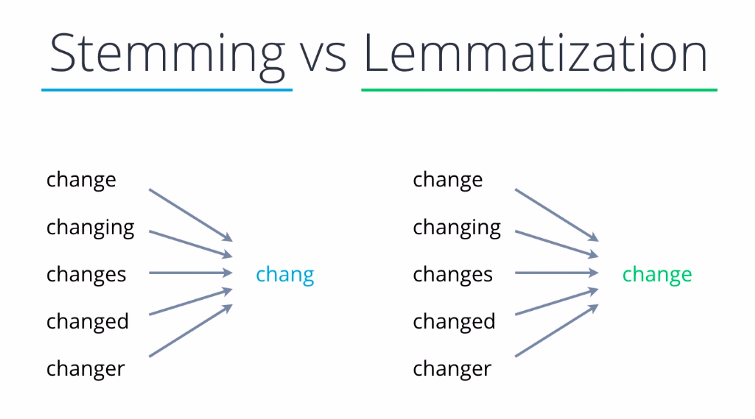

Source: https://nirajbhoi.medium.com/stemming-vs-lemmatization-in-nlp-efc280d4e845

In [11]:
from nltk.stem import PorterStemmer as stemmer
from nltk.stem import WordNetLemmatizer as lemmatizer
from nltk.corpus import wordnet # for robust lemmatization

word = "leaves"

print(stemmer().stem(word))
print(lemmatizer().lemmatize(word, pos = wordnet.NOUN))

leav
leaf


## Part-of-speech Tagging

Words assume specific roles in sentences. Part-of-speech (POS) tagging identifies these roles as the parts of speech, which roughly translates to word categories such as verbs, nouns, adjectives etc.

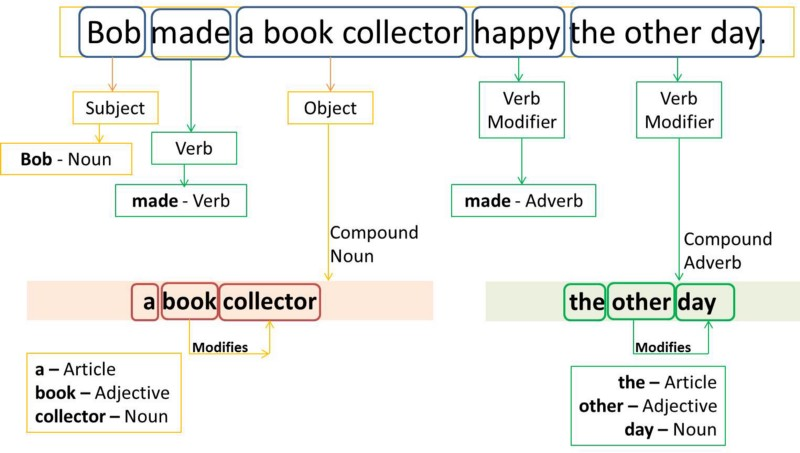

Source: https://www.freecodecamp.org/news/an-introduction-to-part-of-speech-tagging-and-the-hidden-markov-model-953d45338f24/

In [12]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/DubeyA-Dev/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [13]:
# to save us some typing, we import these, so we can call them directly
from nltk import word_tokenize, pos_tag

sentence = "Hope, is the only thing stronger than fear."

# first we tokenize then we pos_tag
sentence = pos_tag(word_tokenize(sentence))

sentence

[('Hope', 'NNP'),
 (',', ','),
 ('is', 'VBZ'),
 ('the', 'DT'),
 ('only', 'JJ'),
 ('thing', 'NN'),
 ('stronger', 'JJR'),
 ('than', 'IN'),
 ('fear', 'NN'),
 ('.', '.')]

At this point, catch all the verbs for our novel:

In [14]:
import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

# Initialize the lemmatizer once
lemmatizer = WordNetLemmatizer()

# Define a function to lemmatize words as verbs
def lemmatize_verb(word):
    # Use the lemmatize method with the correct part of speech
    return lemmatizer.lemmatize(word.lower(), pos= wordnet.VERB)

pos = pos_tag(word_tokenize(story))

# List comprehension to apply lemmatization to verbs
verbs = [lemmatize_verb(word) for word, tag in pos if tag.startswith('V')]

# Output the first few processed verbs
print(verbs[:50])


['be', 'copy', 'give', 're-use', 'include', 'be', 'locate', 'have', 'check', 'be', 'locate', 'use', 'update', 'help', 'understand', 'be', 'be', 'live', 'spend', 'read', 'delicate', 'come', 'have', 'begin', 'be', 'publish', 'be', 'receive', 'find', 'seem', 'open', 'be', 'dash', 'be', 'arrest', 'be', 'meet', 'read', 'be', 'accuse', 'take', 'read', 'set', 'call', 'be', 'be', 'condemn', 'be', 'take', 'be']


In [15]:
# Count frequency of each verb
verb_counts = pd.Series(verbs).value_counts().reset_index()
verb_counts.columns = ['Verb', 'Frequency']

top_verb_counts = verb_counts.head(50)

# Create a bar chart using Altair
chart = alt.Chart(top_verb_counts).mark_bar().encode(
    x='Verb',
    y='Frequency',
    tooltip=['Verb', 'Frequency']
).properties(
    title='Frequency of Lemmatized Verbs'
)

chart

alt.Chart(...)

# 2. Process

We can break down a text into its elements and categorize these components by their types of words. Next, we'll focus on identifying entities, eliminating non-essential words, and pinpointing the most frequently occurring words.

**Identify Different Entities**


Beyond recognizing types of words, we can also differentiate between various entities present in a text, such as individuals, locations, and organizations. This process is commonly known as Named Entity Recognition (NER).

For this part, we'll switch from using NLTK to employing spaCy's statistical models for the English language. To begin, we import spaCy and load the English language model. You may notice some console output during this process, which you can disregard.

In [16]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [17]:
# onlywords

In [18]:
from nltk.tokenize import word_tokenize

# Load your NLP model, assuming spaCy
nlp = spacy.load('en_core_web_sm')  # Make sure to choose the correct model

sample = ' '.join(onlywords)

tokens = word_tokenize(sample)

# Step 3: Extract the first 1000 tokens (or all if fewer than 500) and re-join into a string for NLP processing
first_1000_tokens = ' '.join(tokens[:1000])

# Step 4: Carry out NLP processing
doc = nlp(first_1000_tokens)

# Step 5: Get the text and entity label of all word entities in the article
entities = [(e.text, e.label_) for e in doc.ents if e.text]

# Step 6: See entities
entities


[('the United States', 'GPE'),
 ('the Project Gutenberg License', 'ORG'),
 ('the United States', 'GPE'),
 ('Dostoyevsky', 'PERSON'),
 ('Constance Garnett Release', 'PERSON'),
 ('January', 'DATE'),
 ('English', 'LANGUAGE'),
 ('John Bickers Dagny', 'PERSON'),
 ('David Widger', 'PERSON'),
 ('PUNISHMENT', 'ORG'),
 ('Constance Garnett', 'PERSON'),
 ('Dostoevsky', 'PERSON'),
 ('English', 'NORP'),
 ('Dostoevsky', 'PERSON'),
 ('five', 'CARDINAL'),
 ('only two', 'CARDINAL'),
 ('Dostoevsky', 'PERSON'),
 ('third', 'ORDINAL'),
 ('Petersburg', 'GPE'),
 ('first', 'ORDINAL'),
 ('Nekrassov', 'PERSON'),
 ('Dostoevsky', 'PERSON'),
 ('one', 'CARDINAL'),
 ('Fourier', 'PERSON'),
 ('Byelinsky', 'PERSON'),
 ('Gogol', 'PERSON'),
 ('Nicholas', 'PERSON'),
 ('Maurice Baring', 'PERSON'),
 ('eight months', 'DATE'),
 ('Mihail Dostoevsky', 'PERSON'),
 ('Thereupon', 'PRODUCT'),
 ('third', 'ORDINAL'),
 ('only a few minutes', 'TIME'),
 ('Plestcheiev', 'PERSON'),
 ('Dourov', 'PERSON'),
 ('Majesty', 'PERSON'),
 ('Grigory

If you are not sure what a given tag stands for, you can ask spaCy to explain() it. Here are the explanations of all entity tags in the text:

In [19]:
tags = [ent[1] for ent in entities] # extract the tag parts
tags = set(tags) # get only the unique tags

# loop through all tags explain them
for tag in tags:
    print(tag, spacy.explain(tag))

ORG Companies, agencies, institutions, etc.
LOC Non-GPE locations, mountain ranges, bodies of water
GPE Countries, cities, states
PERSON People, including fictional
ORDINAL "first", "second", etc.
PRODUCT Objects, vehicles, foods, etc. (not services)
CARDINAL Numerals that do not fall under another type
TIME Times smaller than a day
NORP Nationalities or religious or political groups
LANGUAGE Any named language
DATE Absolute or relative dates or periods


In [20]:
from spacy import displacy

displacy.render(doc, style="ent", jupyter=True) # show the text with colorful highligths

**Remove stop words**

The opposite of particularly interesting entitites are so-called stop words. They are very common and serve as short function words such as "the", "is", "or", "at". In text processing it can be useful to remove these frequent words to focus on those terms that are more specific to a given document.

NLTK actually already includes stop words for several languages, including English:

In [21]:
from nltk.corpus import stopwords as stop

stopwords = stop.words("english")

print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

As a next step we remove the stop words from the short story to focus on those words that carry meaning:

In [22]:
tokens = nltk.word_tokenize(story.lower())

# let's focus on those tokens that contain only letters
lettertokens = [word for word in tokens if word.isalpha()]

# this is a special form called List Comprehensions (you've seen it before)
without_stopwords = [word for word in lettertokens if word not in stopwords]

print(without_stopwords[:50])

['project', 'gutenberg', 'ebook', 'crime', 'punishment', 'ebook', 'use', 'anyone', 'anywhere', 'united', 'states', 'parts', 'world', 'cost', 'almost', 'restrictions', 'whatsoever', 'may', 'copy', 'give', 'away', 'terms', 'project', 'gutenberg', 'license', 'included', 'ebook', 'online', 'located', 'united', 'states', 'check', 'laws', 'country', 'located', 'using', 'ebook', 'title', 'crime', 'punishment', 'author', 'fyodor', 'dostoyevsky', 'translator', 'constance', 'garnett', 'release', 'date', 'march', 'ebook']


**Pack a bag of words**

A common representation of text documents is the bag-of-words model, which simply considers a given text as a set of words, disregarding sentence or document structure. Typically, a bag-of-words representation is combined with the frequency of words in a document.

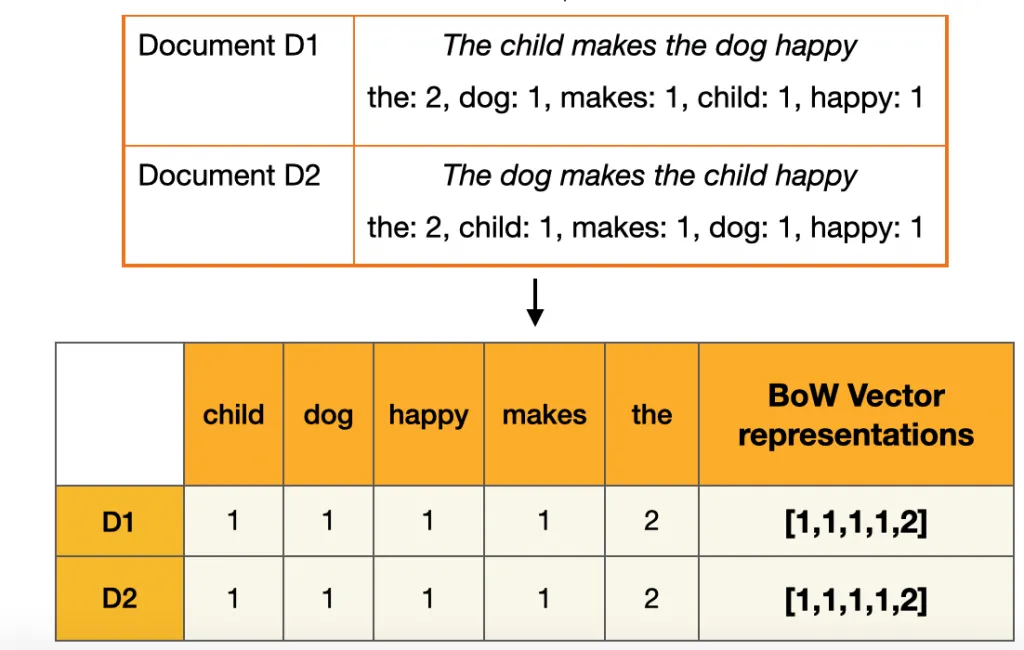

Source: https://aiml.com/what-are-the-advantages-and-disadvantages-of-bag-of-words-model/

In [23]:
import random

# bag of words as a dictionary data type
bow = {}

#use sampling regarding the time constraints
if len(without_stopwords) >= 20000:
    sampled_words = random.sample(without_stopwords, 20000)
else:
    sampled_words = without_stopwords  # Or handle differently if necessary

# we count the occurrences of each word and save it
for word in sampled_words:
    bow[word] = without_stopwords.count(word)

# for later use, we create a sorted list of word-frequency tuples
words_frequency = sorted(bow.items(), key=lambda x: x[1], reverse=True)

print(words_frequency[0:100])

[('raskolnikov', 782), ('one', 637), ('would', 572), ('know', 524), ('said', 518), ('could', 496), ('come', 476), ('man', 474), ('like', 452), ('though', 443), ('sonia', 399), ('see', 383), ('time', 376), ('go', 360), ('went', 355), ('razumihin', 344), ('even', 340), ('dounia', 321), ('well', 317), ('thought', 306), ('must', 303), ('ivanovna', 301), ('suddenly', 293), ('say', 293), ('looked', 293), ('something', 292), ('little', 286), ('petrovitch', 286), ('nothing', 280), ('last', 278), ('room', 276), ('still', 269), ('began', 265), ('away', 263), ('yes', 262), ('way', 251), ('face', 249), ('eyes', 246), ('two', 242), ('came', 242), ('cried', 240), ('tell', 238), ('made', 231), ('without', 228), ('first', 225), ('door', 224), ('almost', 217), ('katerina', 216), ('right', 216), ('mother', 214), ('may', 209), ('perhaps', 208), ('get', 207), ('think', 206), ('svidrigaïlov', 205), ('let', 204), ('porfiry', 204), ('make', 203), ('moment', 203), ('old', 202), ('woman', 200), ('looking', 197

# 3.Present

Now, let's transform these words into visual representations!

**Word Cloud**

Among the various techniques for text visualization, the word cloud (also known as a tag cloud) has garnered significant attention. Despite its limited perceptual and analytical capabilities, it became popular in the 2000s during the Web 2.0 era, largely due to its straightforwardness. The principle is simple: the more frequently a word appears, the larger it is displayed. While Altair doesn't support word clouds directly, we can use a dedicated word cloud generator along with matplotlib to create these visualizations. The word cloud library is particularly user-friendly, as it only requires the raw text to generate a cloud.

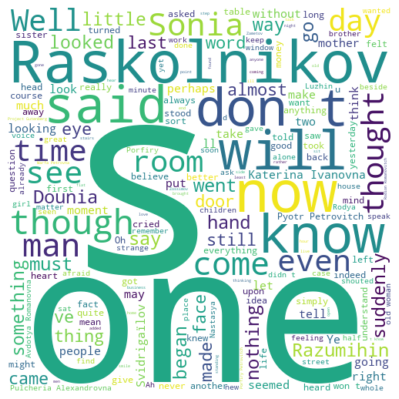

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = story
wc = WordCloud(width=500, height=500, background_color="white").generate(text)

# display the generated image:
my_dpi = 72
plt.figure(figsize = (500/my_dpi, 500/my_dpi), dpi=my_dpi)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

We draw a barchart of the most frequent words (excluding the stop words).

In [25]:
# first we create a dataframe from the word frequencies
df = pd.DataFrame(words_frequency, columns=['word', 'count'])

# we want to focus just on the top 20 words
df_top = df[:20]

# draw horizontal barchart
alt.Chart(df_top).mark_bar().encode(
    x = 'count:Q',
    y = 'word:N'
)

alt.Chart(...)

# All words by type

Through POS tagging we are able to identify the different word types, such as nouns, verbs, adjectives, adverbs, and several others. So let's do exactly this and distinguish between these common word types for the article:

In [26]:
# first we extract all words and their types (a.k.a. parts-of-speech or POS)
pos = pos_tag(word_tokenize(story))

# we will be collecting words and types in lists of the same length
words = []
types = []

# iterate over all entries in the pos list (generated above)
for p in pos:
    # get the word and turn it into lowercase
    word = p[0].lower()
    # get the word's type
    tag = p[1]

    # for this analysis we remove entries that contain punctuation or numbers
    # and we also ignore the stopwords (sorry: the, and, or, etc!)
    if word.isalpha() and word not in stopwords:
        # first we add this word to the words list
        words.append(word)
        # then we add its word type to types list, based on the 1st letter of the pos tag
        # note that we access letters in a string, like entries in a list
        if   (tag[0]=="J"): types.append("Adjective")
        elif (tag[0]=="N"): types.append("Noun")
        elif (tag[0]=="R"): types.append("Adverb")
        elif (tag[0]=="V"): types.append("Verb")
        # there are many more word types, we simply subsume them under 'other'
        else: types.append("Other")

In [27]:
words

['project',
 'gutenberg',
 'ebook',
 'crime',
 'punishment',
 'ebook',
 'use',
 'anyone',
 'anywhere',
 'united',
 'states',
 'parts',
 'world',
 'cost',
 'almost',
 'restrictions',
 'whatsoever',
 'may',
 'copy',
 'give',
 'away',
 'terms',
 'project',
 'gutenberg',
 'license',
 'included',
 'ebook',
 'online',
 'located',
 'united',
 'states',
 'check',
 'laws',
 'country',
 'located',
 'using',
 'ebook',
 'title',
 'crime',
 'punishment',
 'author',
 'fyodor',
 'dostoyevsky',
 'translator',
 'constance',
 'garnett',
 'release',
 'date',
 'march',
 'ebook',
 'recently',
 'updated',
 'january',
 'language',
 'english',
 'information',
 'formats',
 'credits',
 'john',
 'bickers',
 'dagny',
 'david',
 'widger',
 'start',
 'project',
 'gutenberg',
 'ebook',
 'crime',
 'punishment',
 'crime',
 'punishment',
 'fyodor',
 'dostoevsky',
 'translated',
 'constance',
 'garnett',
 'translator',
 'preface',
 'words',
 'dostoevsky',
 'may',
 'help',
 'english',
 'reader',
 'understand',
 'work',
 

In [28]:
types

['Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Adverb',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Adverb',
 'Noun',
 'Adverb',
 'Other',
 'Verb',
 'Verb',
 'Adverb',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Verb',
 'Noun',
 'Noun',
 'Verb',
 'Noun',
 'Noun',
 'Verb',
 'Noun',
 'Noun',
 'Verb',
 'Verb',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Adverb',
 'Verb',
 'Noun',
 'Noun',
 'Adjective',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Other',
 'Verb',
 'Adjective',
 'Noun',
 'Verb',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Noun',
 'Adverb',
 'Adjective',
 'Noun',
 'Adjective',
 'Verb',
 'Other',
 'Noun',
 'Other',
 'Noun',
 'Noun',
 'Noun',
 'Verb',
 'Noun',
 'Verb',
 'Noun',
 'Noun',
 'Adverb',

In [29]:
df

,word,count
0,raskolnikov,782
1,one,637
2,would,572
3,know,524
4,said,518
...,...,...
4702,essentials,1
4703,convention,1
4704,ransack,1
4705,injurious,1


With this information, we can now create two coordinated charts: one representing the frequency of the different word types and the other displaying the frequency of all words (given the current selection). But first things first: somebody get us a DataFrame quick!

In [30]:
# with the two lists of the same length, we create a dataframe with a dictionary,
# of which the keys will become the column labels
df = pd.DataFrame({"word": words, "type": types })

# Filter the dataframe to include only the first 5000 rows
# This step prevents hitting the MaxRowsError in Altair
if len(df) > 5000:
    df = df.head(5000)

# along the type column, we want to support a filter selection
selection = alt.selection_single(fields=["type"])

# we create a composite chart consisting of two sub-charts
# the base holds it together and acts as the concierge taking care of the data
base = alt.Chart(df)

# this shows the types, note that we rely on Altair's aggregation prowess
chart1 = base.mark_bar().encode(
    x = alt.Y('type:N'),
    y = alt.X('count()'),
    # when a bar is selected, the others are displayed with reduced opacity
    opacity=alt.condition(selection, alt.value(1), alt.value(.25)),
).add_params(selection)


# this chart reacts to the selection made in the left/above chart
chart2 = base.mark_bar().encode(
    x = alt.X('word:N'),
    y = alt.Y('count()'),
).add_params(selection)

chart1

/Users/DubeyA-Dev/opt/anaconda3/envs/teaching/lib/python3.10/site-packages/altair/utils/deprecation.py:65: AltairDeprecationWarning: 'selection_single' is deprecated.  Use 'selection_point'
  warnings.warn(message, AltairDeprecationWarning, stacklevel=1)


alt.Chart(...)